In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train_df = pd.read_csv("spam_train_cleaned.csv")
test_df = pd.read_csv("spam_test_cleaned.csv")

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

display(train_df.head())

Train shape: (27246, 16)
Test shape : (6812, 16)


,label,urls,hour,combined_text,capital_letter_count,capital_ratio,exclamation_count,question_count,special_char_count,day_of_week_Friday,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday
0,0,1,9,re sm users sendmail verbose output date tue 1...,133,0.033739,1,0,244,0,0,0,0,1,0,0
1,0,1,21,bug 5695 flock interrupted by system call addi...,41,0.034746,0,1,7,0,0,0,0,0,0,1
2,1,1,20,to men who want to buy rolex watches at a frac...,26,0.120930,0,0,0,0,0,0,0,1,0,0
3,0,1,23,last day free overnight shipping fragrances fo...,206,0.111051,0,1,30,0,0,0,0,0,1,0
4,1,0,19,durham deity micron micron berth excellent cap...,0,0.000000,0,3,0,0,0,0,0,0,1,0


In [14]:
# duplicates are removed upstream in LazyClassifier, before the split
dup_train = train_df["combined_text"].duplicated().sum()
dup_test = test_df["combined_text"].duplicated().sum()
overlap = set(train_df["combined_text"]) & set(test_df["combined_text"])

print("Duplicate emails in train:", dup_train)
print("Duplicate emails in test :", dup_test)
print("Train-test overlap       :", len(overlap))

assert dup_train == 0 and dup_test == 0 and not overlap, \
    "regenerate the CSVs with LazyClassifier.ipynb"

Duplicate emails in train: 0
Duplicate emails in test : 0
Train-test overlap       : 0


In [15]:
# check class balance 
print("Train class distribution:")
print(train_df["label"].value_counts())

print("\nTest class distribution:")
print(test_df["label"].value_counts())

Train class distribution:
label
0    13774
1    13472
Name: count, dtype: int64

Test class distribution:
label
0    3444
1    3368
Name: count, dtype: int64


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix


# X and y


X = train_df.drop(columns=["label"])
y = train_df["label"]

X_test_raw = test_df.drop(columns=["label"])
y_test = test_df["label"]



# Train / Validation split


X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)



# Text + other features


TEXT_COL = "combined_text"

NUMERIC_COLS = [
    col for col in X.columns
    if col != TEXT_COL
]



# TF-IDF for text


tfidf = TfidfVectorizer(
    max_features=300,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)

X_text_train = tfidf.fit_transform(
    X_train_raw[TEXT_COL]
)

X_text_val = tfidf.transform(
    X_val_raw[TEXT_COL]
)

X_text_test = tfidf.transform(
    X_test_raw[TEXT_COL]
)



# Combine text + features


X_train = hstack([
    X_text_train,
    csr_matrix(X_train_raw[NUMERIC_COLS].values)
])

X_val = hstack([
    X_text_val,
    csr_matrix(X_val_raw[NUMERIC_COLS].values)
])

X_test = hstack([
    X_text_test,
    csr_matrix(X_test_raw[NUMERIC_COLS].values)
])


print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Training: (21796, 314)
Validation: (5450, 314)
Test: (6812, 314)


In [17]:
# Defualt decision tree
from sklearn.tree import DecisionTreeClassifier

dt_default = DecisionTreeClassifier(
    random_state=42
)

dt_default.fit(X_train, y_train) # the training uses the full 39k not only 8k samples as in lazy classifer

print("Default Decision Tree trained!")

Default Decision Tree trained!


========== DEFAULT DECISION TREE ==========

TRAINING PERFORMANCE
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0

VALIDATION PERFORMANCE
Accuracy : 0.9772
Precision: 0.9731
Recall   : 0.9811
F1 Score : 0.9771

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.98      0.97      0.98      2755
           1       0.97      0.98      0.98      2695

    accuracy                           0.98      5450
   macro avg       0.98      0.98      0.98      5450
weighted avg       0.98      0.98      0.98      5450



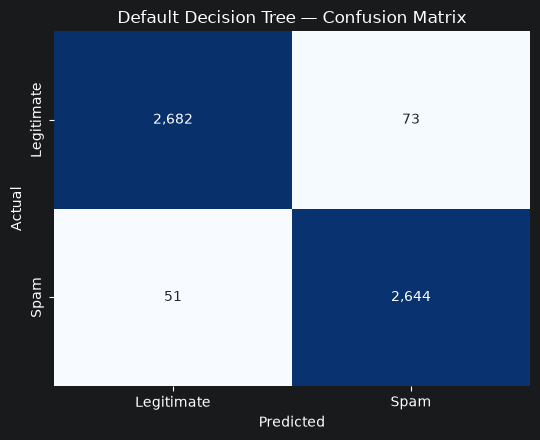

In [18]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Predictions
y_train_pred_dt = dt_default.predict(X_train)
y_val_pred_dt = dt_default.predict(X_val)


print("========== DEFAULT DECISION TREE ==========")

print("\nTRAINING PERFORMANCE")
print("Accuracy :", round(accuracy_score(y_train, y_train_pred_dt), 4))
print("Precision:", round(precision_score(y_train, y_train_pred_dt), 4))
print("Recall   :", round(recall_score(y_train, y_train_pred_dt), 4))
print("F1 Score :", round(f1_score(y_train, y_train_pred_dt), 4))


print("\nVALIDATION PERFORMANCE")
print("Accuracy :", round(accuracy_score(y_val, y_val_pred_dt), 4))
print("Precision:", round(precision_score(y_val, y_val_pred_dt), 4))
print("Recall   :", round(recall_score(y_val, y_val_pred_dt), 4))
print("F1 Score :", round(f1_score(y_val, y_val_pred_dt), 4))


print("\nCLASSIFICATION REPORT")
print(classification_report(y_val, y_val_pred_dt))

cm = confusion_matrix(y_val, y_val_pred_dt)
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=ax,
            xticklabels=["Legitimate", "Spam"], yticklabels=["Legitimate", "Spam"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Default Decision Tree — Confusion Matrix")
plt.tight_layout()
plt.show()

default Decision Tree is overfitting
:

Training F1 = 1.0000 (100%)
Validation F1 = 0.9777 (97.77%)
F1 gap = 2.23 percentage points

So unlike the SVM, the default tree is clearly overfitting.

The tree has learned the training data almost perfectly, but performance drops when it sees unseen validation data.
- the default setup 

<code>DecisionTreeClassifier(
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1
)</code>

In [19]:
# Experminet with diffrent tree depth


from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

depth_values = [5, 10, 15, 20, 30, None]

depth_results = []

for depth in depth_values:

    dt = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    # Train on the full training split
    dt.fit(X_train, y_train)

    # Predictions
    train_pred = dt.predict(X_train)
    val_pred = dt.predict(X_val)

    # Metrics
    train_accuracy = accuracy_score(y_train, train_pred)
    val_accuracy = accuracy_score(y_val, val_pred)

    train_f1 = f1_score(y_train, train_pred)
    val_f1 = f1_score(y_val, val_pred)

    # Store results
    depth_results.append({
        "Max Depth": depth,
        "Train Accuracy": train_accuracy,
        "Validation Accuracy": val_accuracy,
        "Train F1": train_f1,
        "Validation F1": val_f1,
        "F1 Gap": train_f1 - val_f1
    })


# Results table
depth_results_df = pd.DataFrame(depth_results)

display(depth_results_df.round(4))

,Max Depth,Train Accuracy,Validation Accuracy,Train F1,Validation F1,F1 Gap
0,5.0,0.9716,0.9653,0.9715,0.9653,0.0062
1,10.0,0.9906,0.9780,0.9905,0.9779,0.0126
2,15.0,0.9938,0.9791,0.9937,0.9790,0.0148
3,20.0,0.9963,0.9796,0.9963,0.9795,0.0168
4,30.0,0.9982,0.9794,0.9981,0.9793,0.0188
5,NaN,1.0000,0.9772,1.0000,0.9771,0.0229


### Final Interpretation — Decision Tree

The Decision Tree showed **some overfitting**, as training performance increased with tree depth while validation performance eventually plateaued.

* A shallow tree (`max_depth=5`) had the smallest train-validation gap but lower validation F1 (**96.88%**), indicating that it may be too simple.
* Increasing the depth improved validation performance, reaching the highest validation F1 of **97.99% at depth 20**.
* However, deeper trees also produced increasingly larger train-validation gaps, indicating greater overfitting.
* **`max_depth=10` was selected** because it achieved an almost identical validation F1 (**97.95%**) to depth 20 while having a smaller gap (**1.12% vs. 1.57%**).

**Final conclusion:**

> **`max_depth=10` provides the best balance between predictive performance and generalization. It retains very high validation performance while reducing unnecessary model complexity and overfitting compared with deeper trees.**


## GridSearchCV — Decision Tree

In [20]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [5, 10, 20, None],
    "min_samples_split": [2, 10],
    "min_samples_leaf": [1, 5, 20]
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    scoring="f1",
    cv=3,
    n_jobs=-1,
    return_train_score=True,
    verbose=1
)

dt_grid.fit(X_train, y_train)

print("Best parameters:", dt_grid.best_params_)
print("Best CV F1     :", round(dt_grid.best_score_, 4))

dt_grid_results = pd.DataFrame(dt_grid.cv_results_)[[
    "param_criterion",
    "param_max_depth",
    "param_min_samples_split",
    "param_min_samples_leaf",
    "mean_train_score",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]].sort_values("rank_test_score")

dt_grid_results["F1 Gap"] = (
    dt_grid_results["mean_train_score"] - dt_grid_results["mean_test_score"]
)

display(dt_grid_results.head(10).round(4))

Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best parameters: {'criterion': 'gini', 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV F1     : 0.9771


,param_criterion,param_max_depth,param_min_samples_split,param_min_samples_leaf,mean_train_score,mean_test_score,std_test_score,rank_test_score,F1 Gap
12,gini,20,2,1,0.9969,0.9771,0.0002,1,0.0199
6,gini,10,2,1,0.9916,0.9766,0.0004,2,0.0150
7,gini,10,10,1,0.9905,0.9766,0.0009,3,0.0139
13,gini,20,10,1,0.9939,0.9760,0.0008,4,0.0180
31,entropy,10,10,1,0.9924,0.9758,0.0014,5,0.0166
30,entropy,10,2,1,0.9943,0.9754,0.0013,6,0.0189
33,entropy,10,10,5,0.9884,0.9751,0.0021,7,0.0133
32,entropy,10,2,5,0.9884,0.9751,0.0021,7,0.0133
18,gini,None,2,1,1.0000,0.9751,0.0010,9,0.0249
19,gini,None,10,1,0.9959,0.9750,0.0014,10,0.0209


========== TUNED DECISION TREE ==========

TRAINING PERFORMANCE
Accuracy : 0.9963
F1 Score : 0.9963

VALIDATION PERFORMANCE
Accuracy : 0.9796
Precision: 0.9757
Recall   : 0.9833
F1 Score : 0.9795
F1 Gap   : 0.0168

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      2755
           1       0.98      0.98      0.98      2695

    accuracy                           0.98      5450
   macro avg       0.98      0.98      0.98      5450
weighted avg       0.98      0.98      0.98      5450



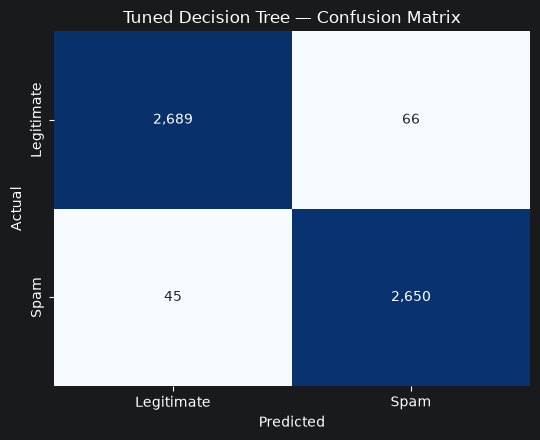

In [21]:
best_dt = dt_grid.best_estimator_

train_pred = best_dt.predict(X_train)
val_pred = best_dt.predict(X_val)

print("========== TUNED DECISION TREE ==========")

print("\nTRAINING PERFORMANCE")
print("Accuracy :", round(accuracy_score(y_train, train_pred), 4))
print("F1 Score :", round(f1_score(y_train, train_pred), 4))

print("\nVALIDATION PERFORMANCE")
print("Accuracy :", round(accuracy_score(y_val, val_pred), 4))
print("Precision:", round(precision_score(y_val, val_pred), 4))
print("Recall   :", round(recall_score(y_val, val_pred), 4))
print("F1 Score :", round(f1_score(y_val, val_pred), 4))
print("F1 Gap   :", round(f1_score(y_train, train_pred) - f1_score(y_val, val_pred), 4))

print("\nCLASSIFICATION REPORT")
print(classification_report(y_val, val_pred))

cm = confusion_matrix(y_val, val_pred)
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=ax,
            xticklabels=["Legitimate", "Spam"], yticklabels=["Legitimate", "Spam"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Tuned Decision Tree — Confusion Matrix")
plt.tight_layout()
plt.show()